# HW3：簡訊垃圾分類（Logistic Regression）

此筆記本涵蓋從資料前處理、特徵工程、模型訓練、評估到視覺化的完整流程。每個程式區塊前都會有繁體中文的說明。
本 notebook 假設已經有清理後的資料集：`D:/test/HW3/sms_spam_clean.csv`，且標籤欄位為 `label`、文字欄位為 `text`。

## 1) 載入套件與設定環境
在此單元說明我們將使用的主要套件與一些顯示/繪圖的預設設定。

In [5]:
# 載入必要套件
import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score, precision_score, recall_score, f1_score)
import joblib

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

## 2) 載入資料並進行概覽
說明：讀取 `sms_spam_clean.csv`，檢查欄位、缺值、以及類別分布。

In [6]:
DATA_PATH = 'D:/test/HW3/sms_spam_clean.csv'
df = pd.read_csv(DATA_PATH)
print('Rows, cols:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Rows, cols: (5573, 2)
Columns: ['label', 'text']


,label,text
0,ham,ok lar joking wif u oni
1,spam,free entry in NUM a wkly comp to win fa cup fi...
2,ham,u dun say so early hor u c already then say
3,ham,nah i don t think he goes to usf he lives arou...
4,spam,freemsg hey there darling it s been NUM week s...


檢視類別分布：我們希望了解 spam / ham 的比例是否失衡。

label
ham     4826
spam     747
Name: count, dtype: int64

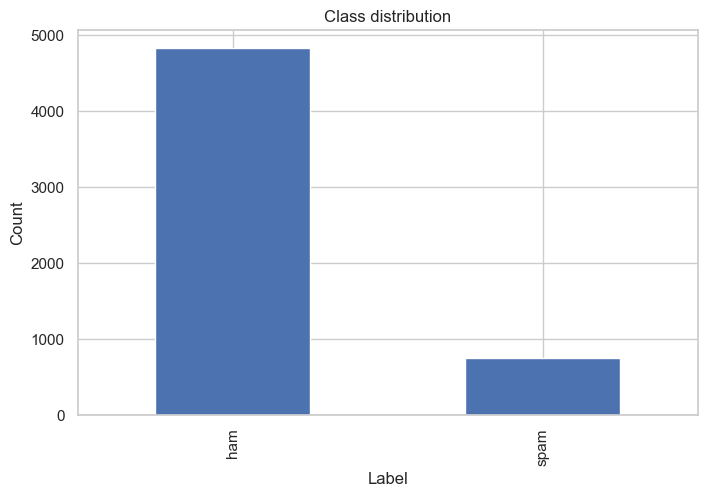

In [7]:
label_col = 'label'
n = df[label_col].value_counts()
display(n)
ax = n.plot(kind='bar')
ax.set_title('Class distribution')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
plt.show()

## 3) 簡單文字探索（token-level）
說明：統計清理後文字中出現頻次最高的詞彙（粗略近似），並比對在 spam/ham 中的差異。

In [8]:
from collections import Counter
def top_tokens(texts, n=30):
    c = Counter()
    for t in texts:
        for w in str(t).split():
            c[w] += 1
    return c.most_common(n)

top_all = top_tokens(df['text'], n=30)
pd.DataFrame(top_all, columns=['token','count']).head(10)

,token,count
0,NUM,4526
1,i,3032
2,to,2253
3,you,2247
4,a,1465
5,the,1343
6,u,1221
7,and,980
8,in,906
9,is,897


觀察 spam 與 ham 各自的前 20 個 token，並繪出比較條形圖。

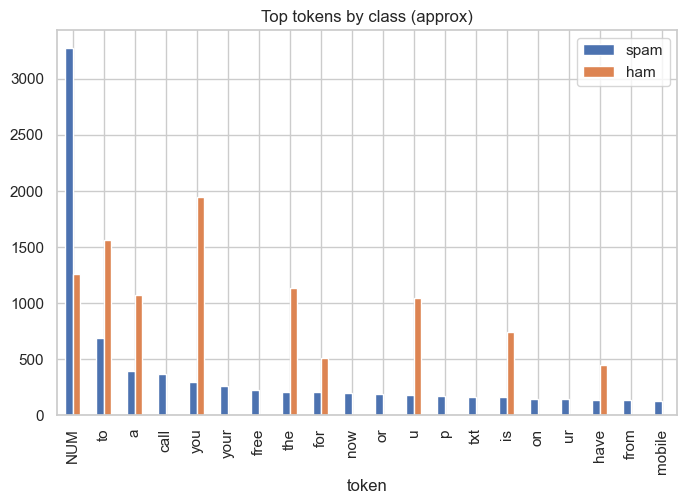

In [9]:
spam_texts = df[df[label_col].astype(str).str.lower().str.contains('spam')]['text']
ham_texts = df[~df[label_col].astype(str).str.lower().str.contains('spam')]['text']
top_spam = dict(top_tokens(spam_texts, n=20))
top_ham = dict(top_tokens(ham_texts, n=20))
tokens = list(set(list(top_spam.keys()) + list(top_ham.keys())))
data = []
for t in tokens:
    data.append({'token': t, 'spam': top_spam.get(t,0), 'ham': top_ham.get(t,0)})
tf = pd.DataFrame(data).sort_values('spam', ascending=False).head(20)
tf.set_index('token')[['spam','ham']].plot(kind='bar', stacked=False)
plt.title('Top tokens by class (approx)')
plt.show()

## 4) 建立訓練/測試集並訓練 Logistic Regression
說明：建立一個 Pipeline（TF-IDF -> LogisticRegression），訓練並輸出基本效能指標。

In [10]:
X = df['text'].astype(str)
y = df['label'].astype(str)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pipe = Pipeline([('tfidf', TfidfVectorizer(max_features=20000)), ('clf', LogisticRegression(max_iter=1000))])
pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)
# 嘗試取 spam 的機率欄位位置
if 'spam' in pipe.classes_:
    spam_index = list(pipe.classes_).index('spam')
else:
    spam_index = 1
probs = pipe.predict_proba(X_test)[:, spam_index]
print(classification_report(y_test, preds))
# 儲存模型
os.makedirs('models', exist_ok=True)
joblib.dump(pipe, 'models/logreg_pipeline.joblib')
print('Saved model to models/logreg_pipeline.joblib')

              precision    recall  f1-score   support

         ham       0.98      0.99      0.98       966
        spam       0.93      0.86      0.90       149

    accuracy                           0.97      1115
   macro avg       0.96      0.92      0.94      1115
weighted avg       0.97      0.97      0.97      1115

Saved model to models/logreg_pipeline.joblib


## 5) 評估：混淆矩陣、ROC 與 Precision-Recall 曲線
說明：視覺化混淆矩陣、ROC 曲線與 Precision-Recall 曲線，並計算 AUC / AP。

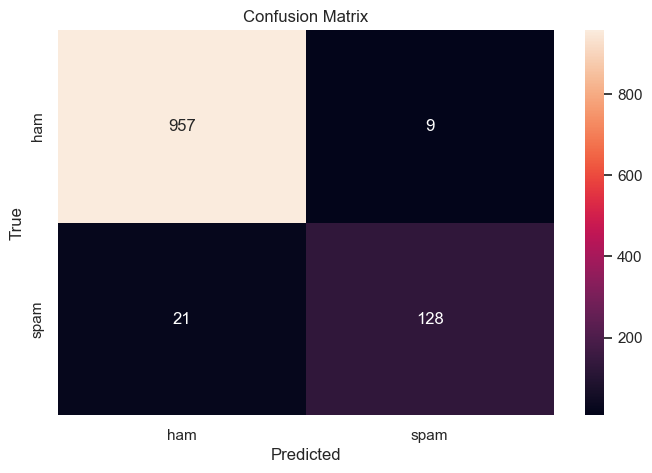

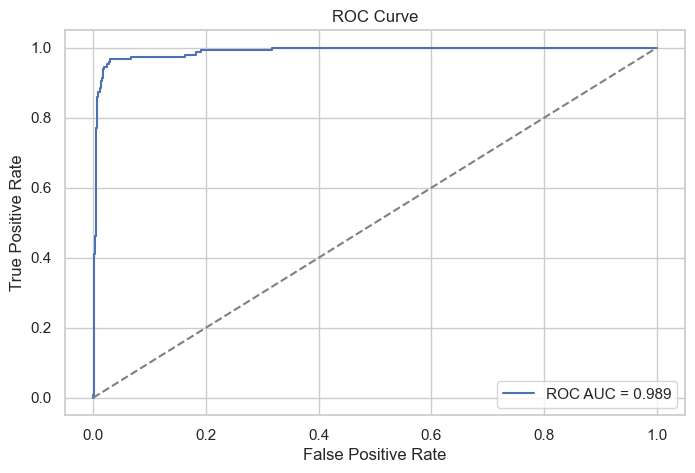

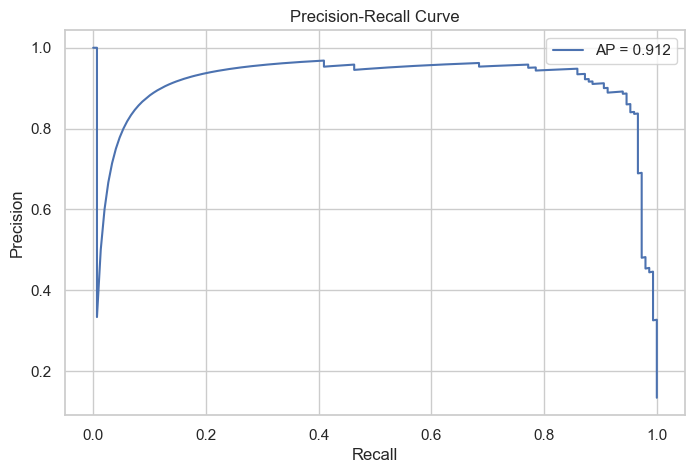

In [11]:
# 混淆矩陣
labels = list(pipe.classes_)
cm = confusion_matrix(y_test, preds, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# ROC
if 'spam' in labels:
    pos_idx = labels.index('spam')
else:
    pos_idx = 1
fpr, tpr, _ = roc_curve((y_test == 'spam').astype(int), probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Precision-Recall
precision, recall, _ = precision_recall_curve((y_test == 'spam').astype(int), probs)
ap = average_precision_score((y_test == 'spam').astype(int), probs)
plt.plot(recall, precision, label=f'AP = {ap:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 6) Threshold Sweep：Precision / Recall / F1 的變化
說明：對預測機率掃描不同閾值，計算 precision/recall/f1，以輔助選擇決策閾值。

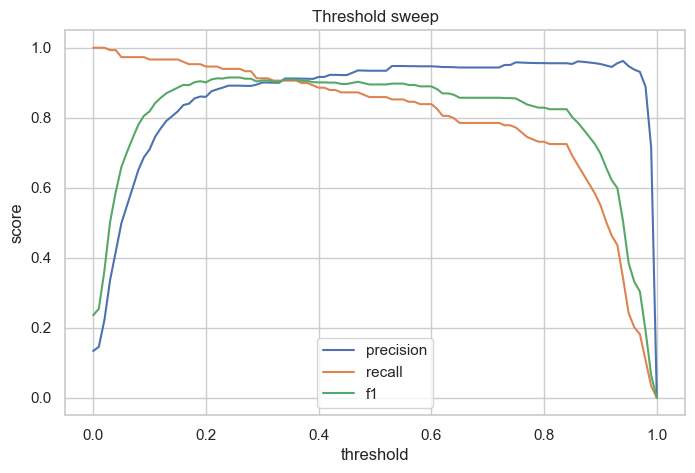

In [12]:
from sklearn.metrics import precision_recall_fscore_support
thresholds = np.linspace(0.0,1.0,101)
rows = []
for t in thresholds:
    preds_t = (probs >= t).astype(int)
    precision = precision_score((y_test == 'spam').astype(int), preds_t, zero_division=0)
    recall = recall_score((y_test == 'spam').astype(int), preds_t, zero_division=0)
    f1 = f1_score((y_test == 'spam').astype(int), preds_t, zero_division=0)
    rows.append({'threshold': t, 'precision': precision, 'recall': recall, 'f1': f1})
ts = pd.DataFrame(rows)
plt.plot(ts['threshold'], ts['precision'], label='precision')
plt.plot(ts['threshold'], ts['recall'], label='recall')
plt.plot(ts['threshold'], ts['f1'], label='f1')
plt.xlabel('threshold')
plt.ylabel('score')
plt.legend()
plt.title('Threshold sweep')
plt.show()

## 7) 存檔、結論與下一步
說明：列出主要結果、模型保存位置，以及下一步可改進之處（例如更複雜的特徵工程、處理不平衡、模型壓縮）。

In [13]:
print('Model saved to models/logreg_pipeline.joblib')
print('Summary:')
print(classification_report(y_test, preds))

# 清理記憶體
del X, y, X_train, X_test, y_train, y_test, preds, probs
gc.collect()

Model saved to models/logreg_pipeline.joblib
Summary:
              precision    recall  f1-score   support

         ham       0.98      0.99      0.98       966
        spam       0.93      0.86      0.90       149

    accuracy                           0.97      1115
   macro avg       0.96      0.92      0.94      1115
weighted avg       0.97      0.97      0.97      1115



17036